In [1]:
import jax
import os
#os.environ["CUDA_VISIBLE_DEVICES"] = "0"
import jax.numpy as jnp
wanted_type_complex = jnp.complex128
wanted_type_real = jnp.float64
print("Devices:", jax.devices())
if not any(d.platform == "gpu" for d in jax.devices()):
    raise RuntimeError("JAX is not using a GPU.")
import sys
sys.path.insert(0, "/home/tmalasda/dev")
from cheb_ar import ChebAr
import numpy as np
import dynamiqs as dq
from scipy.special import jv
import json

n_a = 20
n_b = 8
cheb_degree = 6
m_arnoldi_0 = 60
m_arnoldi_first = 120
m_arnoldi_generic = 80
margin = 5e-3
alpha_sq = 6

OUTPUT_PATH = "/home/tmalasda/output/Cheb_Ar/13_07_2026/cheb_ar_vs_epsp_alphasq_6.json"

def build_ats_hamiltonian(
    n_a=20,
    n_b=11,
    alpha_sq=8.5,
    w_a=25.338776456203686,
    kappa_b=5 / 10.4,
    E_J=37 * 2 * np.pi,
    phi_a=0.11,
    phi_b=0.204,
    epsilon_p=0.1,
    n_periods=1,
):
    """Build the driven full-ATS Lindbladian in the rotating frame.

    Mirrors the operator/Hamiltonian cells of ``Chebyshev-Arnoldi.ipynb``.

    Returns
    -------
    Ham : dynamiqs time-dependent operator
        The rotating-frame Hamiltonian ``Ham_full_r``.
    jump_ops : list
        Lindblad jump operators ``[sqrt(kappa_1) a, sqrt(kappa_b) b]``.
    T_block : float
        Duration of one Floquet block, ``n_periods * 2*pi / w_a``.
    params : dict
        Derived quantities (``g``, ``g2``, ``kappa_1``, ``kappa_2``,
        ``epsilon_d``, ``w_b``, ``T_drive``) for reference.
    """
    w_b = 2 * w_a

    # couplings derived from the pump
    g = np.sin(epsilon_p) * E_J * phi_a**2 * phi_b
    g2 = jv(1, epsilon_p) * E_J * phi_a**2 * phi_b

    kappa_2 = 4 * g**2 / kappa_b
    kappa_1 = 0.005 * kappa_2

    epsilon_d = 2 * alpha_sq * g2

    # Operators
    a = dq.destroy(n_a)
    b = dq.destroy(n_b)
    Ia = dq.eye(n_a)
    Ib = dq.eye(n_b)

    a_tot = dq.tensor(a, Ib)
    b_tot = dq.tensor(Ia, b)

    phi_a_tot = phi_a*(a_tot + dq.dag(a_tot))
    phi_b_tot = phi_b*(b_tot + dq.dag(b_tot))

    non_linear_op = dq.sinm(phi_a_tot + phi_b_tot) - phi_a_tot - phi_b_tot

    H_drive = dq.modulated(
        lambda t: epsilon_d * jnp.cos(w_b*t),
        b_tot + dq.dag(b_tot)
        )

    H_0 = w_a*a_tot@dq.dag(a_tot) + w_b*b_tot@dq.dag(b_tot)

    Ham = H_0 + H_drive - 2*E_J*jnp.sin(epsilon_p)*non_linear_op 

    jump_ops = [
        jnp.sqrt(kappa_1) * a_tot,
        jnp.sqrt(kappa_b) * b_tot,
    ]

    T_drive = 2 * jnp.pi / w_a
    T_block = n_periods * T_drive

    params = {
        "g": g,
        "g2": g2,
        "kappa_1": kappa_1,
        "kappa_2": kappa_2,
        "kappa_b": kappa_b,
        "epsilon_d": epsilon_d,
        "w_a": w_a,
        "w_b": w_b,
        "T_drive": T_drive,
    }
    return Ham, jump_ops, T_block, params

def _to_jsonable(obj):
    """Recursively convert jax/numpy arrays and complex numbers to JSON types.

    Complex values become ``{"real": ..., "imag": ...}``; arrays become nested
    lists; numpy/jax scalars become plain Python ``int``/``float``.
    """
    if isinstance(obj, dict):
        return {k: _to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_to_jsonable(v) for v in obj]
    # jax / numpy arrays -> numpy, then recurse on the python object
    if isinstance(obj, (jax.Array, np.ndarray)):
        return _to_jsonable(np.asarray(obj).tolist())
    if isinstance(obj, (np.complexfloating, complex)):
        return {"real": float(obj.real), "imag": float(obj.imag)}
    if isinstance(obj, (np.floating, float)):
        return float(obj)
    if isinstance(obj, (np.integer, int)):
        return int(obj)
    return obj

def run_for_epsp(eps_p, m_arnoldi, x0 = None):
    """Run the full Chebyshev-Arnoldi pipeline for one value of ``eps_p``.

    Returns a JSON-serializable dict with ``rate_bf``, ``x_ritz`` and ``res``.
    """
    Ham_full_r, jump_ops, T_block, params = build_ats_hamiltonian(
        n_a=n_a, n_b=n_b, epsilon_p=eps_p, alpha_sq=alpha_sq
    )

    solver = ChebAr(
        Ham_full_r, jump_ops, n_a=n_a, n_b=n_b, T_block=T_block, cheb_degree=cheb_degree
    )

    if x0 is  None: x0 = solver.make_x0(seed=0)

    _, _, ritz_vals = solver.first_estimation(x0, m_arnoldi=m_arnoldi_0)

    solver.setup_chebyshev(ritz_vals, margin=margin)

    Q, H, mu_list = solver.arnoldi_hessenberg(x0, solver.chebyshev_filter, m_arnoldi)

    rate_bf = solver.rate_from_mu(mu_list[-1])
    x_ritz, _ = solver.ritz_vector(Q, H, m_arnoldi)
    res = solver.residual_check(x_ritz)

    return {
        "eps_p": eps_p,
        "n_a": n_a,
        "n_b": n_b,
        "cheb_degree": cheb_degree,
        "m_arnoldi_0": m_arnoldi_0,
        "m_arnoldi": m_arnoldi,
        "rate_bf": _to_jsonable(rate_bf),
        "x_ritz": _to_jsonable(x_ritz),
        "res": _to_jsonable(res),
        "params": _to_jsonable(params),
    }

Devices: [CudaDevice(id=0), CudaDevice(id=1), CudaDevice(id=2), CudaDevice(id=3)]


In [2]:
eps_p_list = np.linspace(0.1, 1.1, 6)
eps_p = eps_p_list[0]
Ham_full_r, jump_ops, T_block, params = build_ats_hamiltonian(
    n_a=n_a, n_b=n_b, epsilon_p=eps_p, alpha_sq=alpha_sq
)

solver = ChebAr(
    Ham_full_r, jump_ops, n_a=n_a, n_b=n_b, T_block=T_block, cheb_degree=cheb_degree
)

x0 = solver.make_x0(seed=0)

_, _, ritz_vals = solver.first_estimation(x0, m_arnoldi=m_arnoldi_0)

solver.setup_chebyshev(ritz_vals, margin=margin)

/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/equinox/_module/_prebuilt.py:46: UserWarning: A `SparseDIADataArray` has been converted to a `DenseDataArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)
/home/tmalasda/dynamiqs/dynamiqs/qarrays/dataarray.py:287: UserWarning: A sparse data array has been converted to dense layout due to element-wise addition with a dense data array.
  return self.__add__(y)
|██████████| 100.0% ◆ elapsed 518.09ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 471.06ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 458.69ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 436.24ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 422.01ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 392.80ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 378.23ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 373.99ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 373.45ms ◆ remaining 0

{'center_a': np.complex128(0.35704513037035657-1.9288282674647338e-16j),
 'semi_re': np.float64(0.6307385047661958),
 'semi_im': np.complex128(0.7199976835861246-5.731423870691066e-17j),
 'ritz_bitflip': np.complex128(0.9927836351365523-2.444976351719723e-16j),
 'vertex_x': np.complex128(0.9877836351365523-2.444976351719723e-16j),
 'margin': 0.005,
 'max_level': 0.9949999999999998,
 'ritz_vals_enc': array([-0.107703  +4.83219023e-01j, -0.1070369 +4.80988883e-01j,
        -0.05228883+5.12664531e-01j, -0.03094007+5.09825440e-01j,
         0.00512061+5.56628133e-01j,  0.04584164+5.61543840e-01j,
         0.0663089 +4.79480533e-01j,  0.12799079+6.04396665e-01j,
         0.20341998+6.96456483e-01j,  0.17786125+6.26063703e-01j,
         0.23141979+6.57617402e-01j,  0.27739248+6.93672419e-01j,
         0.33670575+6.95420855e-01j,  0.38176271+6.95544687e-01j,
         0.42690383+6.45760923e-01j,  0.48714255+6.23645496e-01j,
         0.53532897+5.97631547e-01j,  0.3261128 +4.66918422e-01j,
    

/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


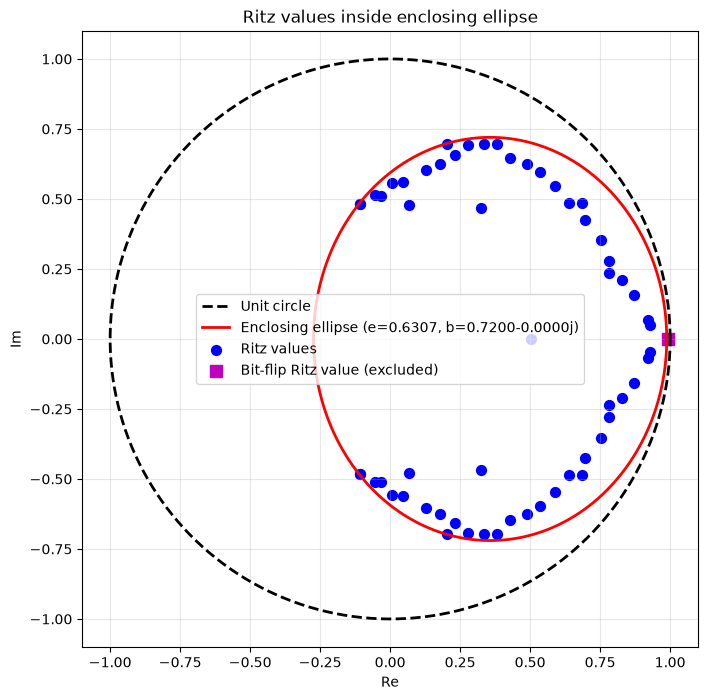

In [3]:
import matplotlib.pyplot as plt
# Plot
fig, ax = plt.subplots(figsize=(8, 8))

# Unit circle
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), 'k--', label='Unit circle', linewidth=2)

# Enclosing ellipse
ax.plot(solver.ellipse['center_a'] + solver.ellipse['semi_re']*np.cos(theta), solver.ellipse['semi_im']*np.sin(theta), 'r-',
        label=f"Enclosing ellipse (e={solver.ellipse['semi_re']:.4f}, b={solver.ellipse['semi_im']:.4f})", linewidth=2)

# Ritz values (enclosed)
ax.scatter(solver.ellipse['ritz_vals_enc'].real, solver.ellipse['ritz_vals_enc'].imag, c='b', s=50, label='Ritz values')

# Excluded bit-flip Ritz value
ax.scatter(ritz_vals[solver.ellipse['idx_bitflip']].real, ritz_vals[solver.ellipse['idx_bitflip']].imag,
           c='m', s=80, marker='s', label='Bit-flip Ritz value (excluded)')

ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlabel('Re')
ax.set_ylabel('Im')
ax.set_title('Ritz values inside enclosing ellipse')
plt.show()

In [4]:
m_arnoldi = 50
Q, H, mu_list = solver.arnoldi_hessenberg(x0, solver.chebyshev_filter, m_arnoldi)

|██████████| 100.0% ◆ elapsed 496.97ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 453.99ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 558.59ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 693.15ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 765.70ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 801.61ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 382.63ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 420.96ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 514.69ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 603.84ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 679.88ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 723.90ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 339.90ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 381.89ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 471.93ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 571.16ms ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 647.63ms ◆

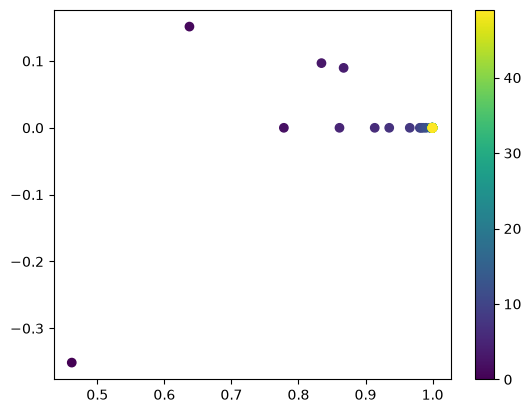

In [6]:
plt.scatter(np.real(mu_list), np.imag(mu_list), c=range(m_arnoldi))
plt.colorbar()
plt.show()